In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import subprocess

update_data = True

## Izbriši podatke v mapi `RESULTS`

In [ ]:
# Izbriši podatke v mapi `RESULTS`

if update_data:
    subprocess.run("rm -rf RESULTS", shell=True, check=True)
    subprocess.run("mkdir RESULTS", shell=True, check=True)
    subprocess.run("g++ -Ofast ./main.cpp -o run", shell=True, check=True)

    for T in [0.01,0.1,0.5,1.0,5.0]:
        print(f"Poteka simulacija za T = {T}")
        subprocess.run(f"./run {T}", shell=True, check=True)

Poteka simulacija za T = 0.1


KeyboardInterrupt: 

In [ ]:
# Preveri, ali imenik "RESULTS" obstaja, da se izogne napaki
if not os.path.exists("RESULTS"):
    print("Imenik 'RESULTS' ne obstaja.")
    exit()

files = os.listdir('RESULTS')

r_min = []
lege = []
T = []
gr = []

for file in files:
    info = file.split("_")
    if file.endswith('.txt'):
        path = os.path.join('RESULTS', file)
        try:
            data = np.loadtxt(path)
            if "min_dist" in file:
                r_min.append(file)
            if "pozicije" in file:
                lege.append(file)
            if "temperatura" in file:
                T.append(file)
            if "gr" in file:
                gr.append(file)
        except Exception as e:
            print(f"Napaka pri branju datoteke {file}: {e}")

print("r_min:", r_min)
print("lege:", lege)
print("T:", T)
print("gr:", gr)


r_min: ['1_T_min_dist.txt', '0dp1_T_min_dist.txt', '0dp5_T_min_dist.txt', '5_T_min_dist.txt']
lege: ['0dp1_T_pozicije.txt', '5_T_pozicije.txt', '0dp5_T_pozicije.txt', '1_T_pozicije.txt']
T: ['0dp5_T_temperatura.txt', '0dp1_T_temperatura.txt', '1_T_temperatura.txt', '5_T_temperatura.txt']
gr: ['0dp5_T_gr.txt', '5_T_gr.txt', '1_T_gr.txt', '0dp1_T_gr.txt']


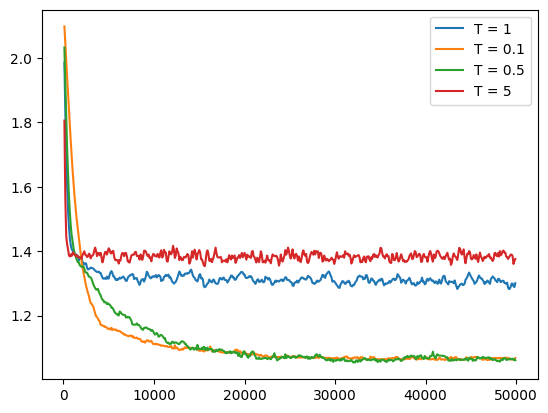

In [ ]:
for file in r_min:
    label = "T = " + file.split("_")[0].replace("dp",".")
    data = np.loadtxt('RESULTS/'+file)
    plt.plot(data[:,0],data[:,1],label=label)
plt.legend()
plt.show()

# Temperatura

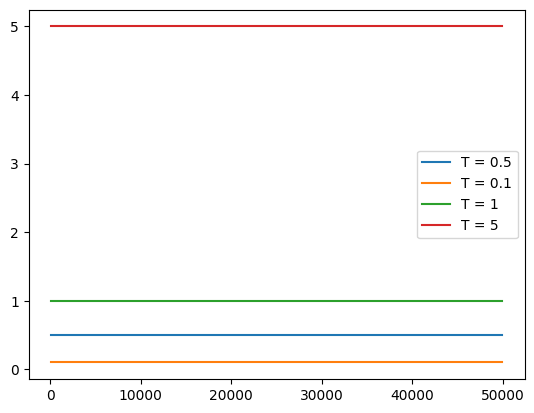

In [ ]:
for file in T:
    label = "T = " + file.split("_")[0].replace("dp",".")
    data = np.loadtxt('RESULTS/'+file)
    plt.plot(data[:,0],data[:,1],label=label)
plt.legend()
plt.show()

## Hitrost

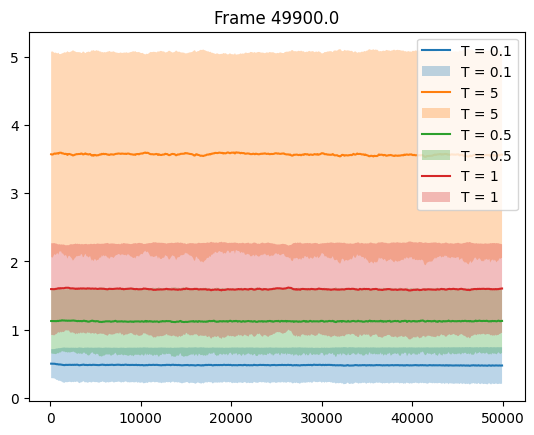

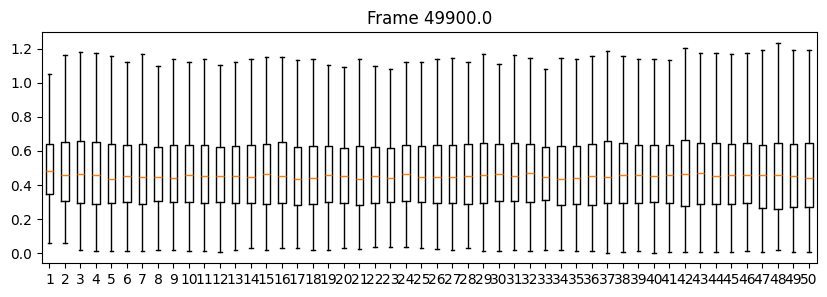

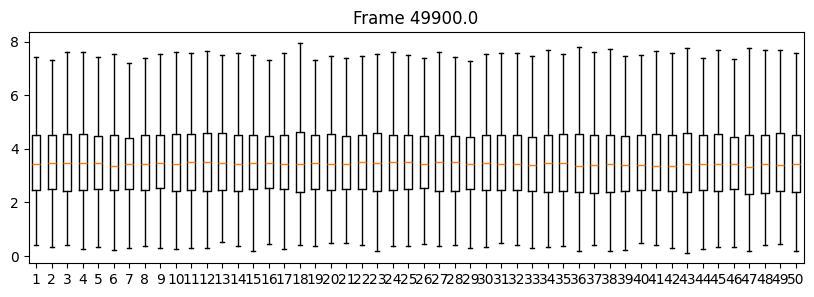

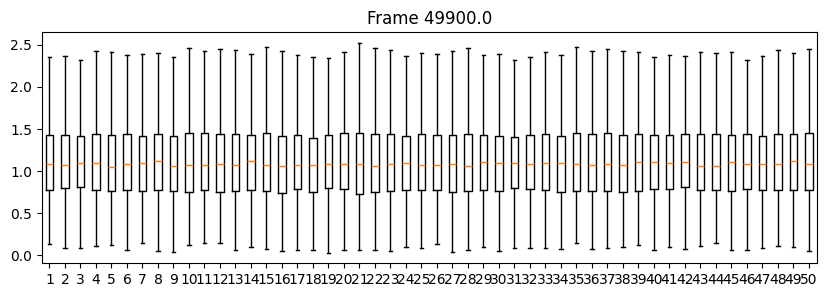

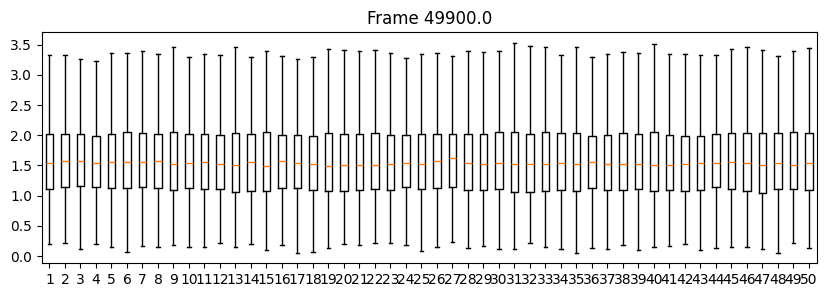

In [ ]:
plt.figure()
for file in lege:
    data = np.loadtxt('RESULTS/' + file)
    T = file.split("_")[0].replace("dp",".")
    frames = np.unique(data[:,0])
    y_mean = []
    y_max = []
    y_min = []
    for frame in frames:
        y = data[data[:,0]==frame,4]
        y_mean.append(np.mean(y))
        y_max.append(np.mean(y)+np.std(y))
        y_min.append(np.mean(y)-np.std(y))
    plt.plot(frames,y_mean,label= f"T = {T}")
    plt.fill_between(frames,y_min,y_max,alpha=0.3,label = f"T = {T}")
plt.legend()
plt.title(f"Frame {frame}")
plt.show()



for file in lege:
    data = np.loadtxt('RESULTS/' + file)
    T = file.split("_")[0].replace("dp",".")
    frames = np.unique(data[:,0])
    y = []
    x = []
    for i,frame in enumerate(frames):
        if i%10==0:
            y.append(data[data[:,0]==frame,4])
            x.append(frame)
    plt.figure(figsize=(10,3))
    plt.boxplot(y, showfliers=False)
    plt.title(f"Frame {frame}")
    plt.show()

# Prikaz system

/tmp/ipykernel_9004/70097478.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_9004/70097478.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


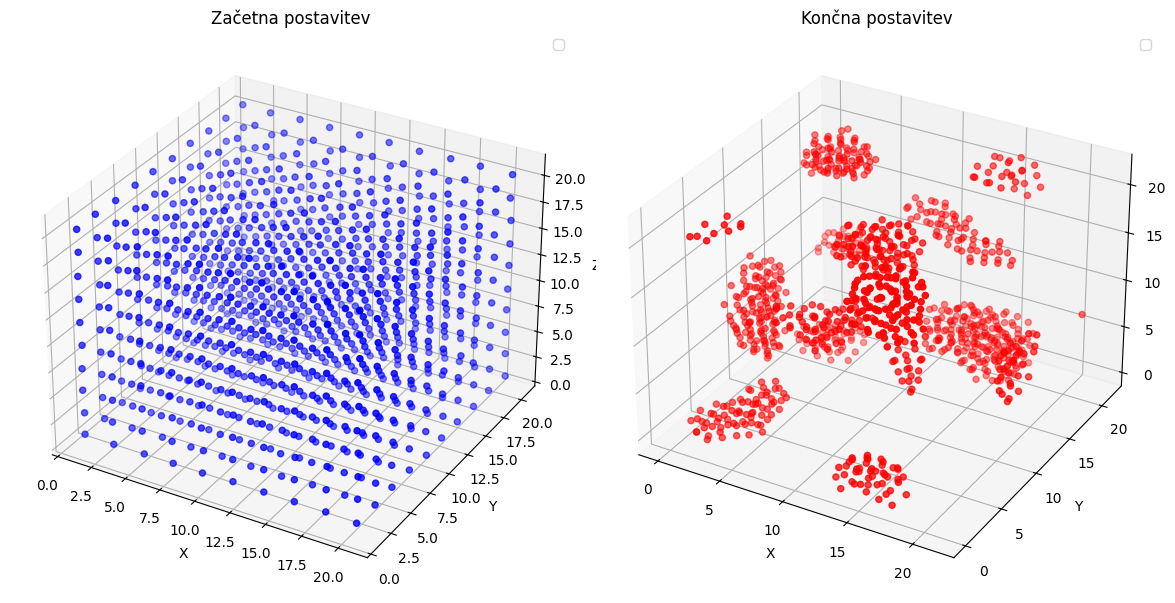

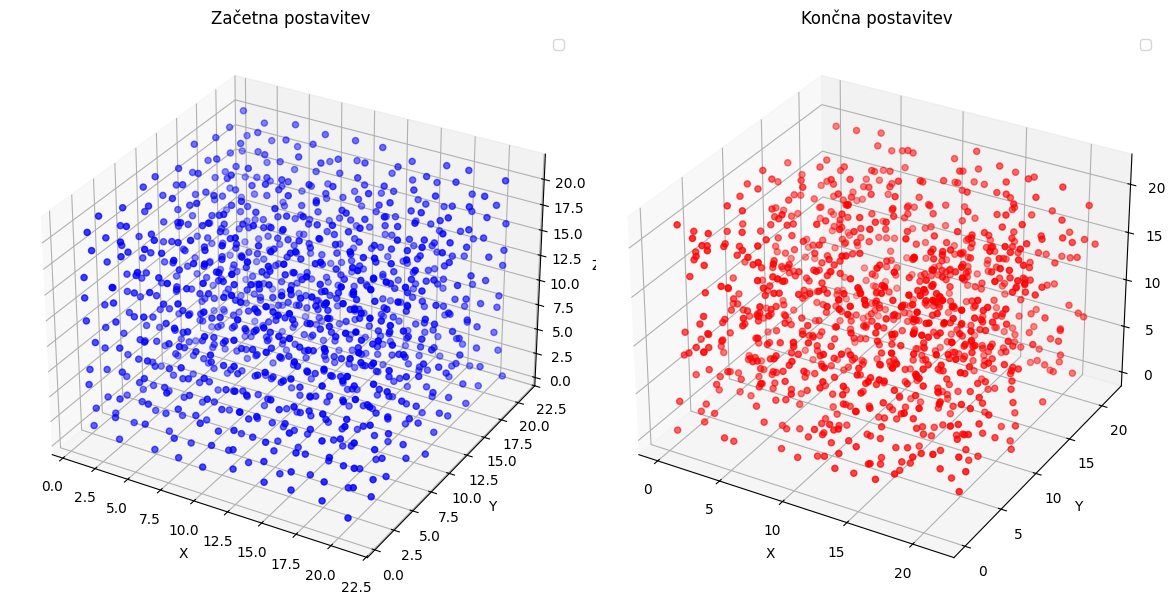

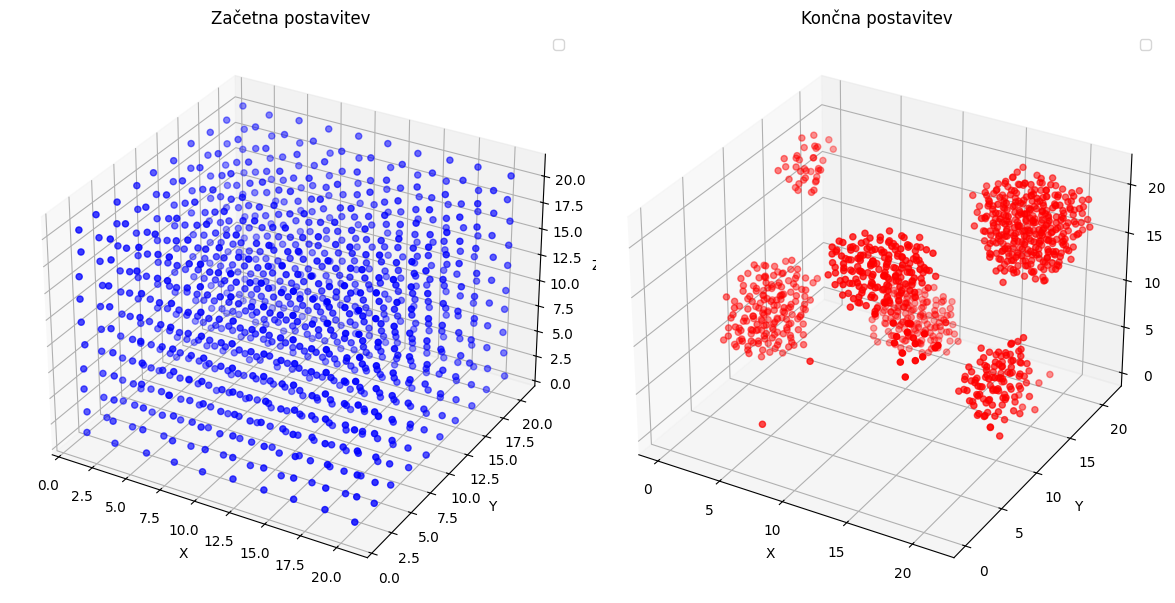

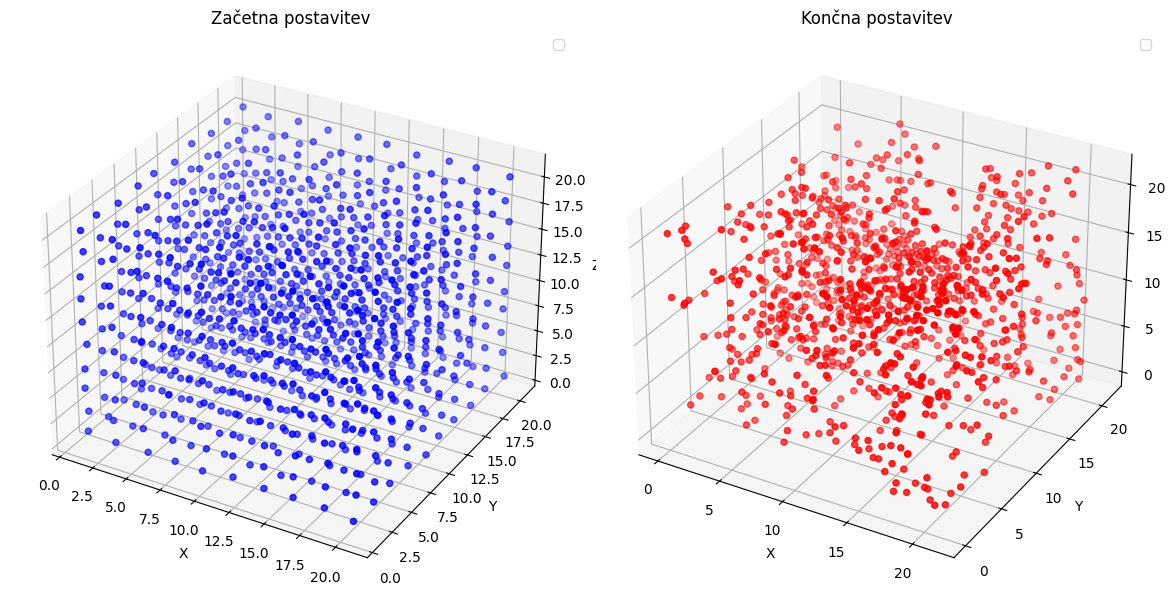

In [ ]:
# 3D projekcija system
from mpl_toolkits.mplot3d import Axes3D

for file in lege:
    data = np.loadtxt('RESULTS/' + file)
    
    # Use isclose for robust time matching (optional)
    t_min = data[:, 0].min()
    t_max = data[:, 0].max()
    
    select_init = np.where(np.isclose(data[:, 0], t_min))[0]
    init_pos = data[select_init, 1:]
    
    select_final = np.where(np.isclose(data[:, 0], t_max))[0]
    final_pos = data[select_final, 1:]
    
    fig = plt.figure(figsize = (12,6),dpi = 99)

    # Create a 1x2 grid of subplots and get each axis for 3D plotting
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122, projection='3d')

    # Plot the initial positions on the first subplot
    ax1.scatter(init_pos[:, 0], init_pos[:, 1], init_pos[:, 2], color='b')
    ax1.set_title("Začetna postavitev")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    ax1.legend()

    # Plot the final positions on the second subplot
    ax2.scatter(final_pos[:, 0], final_pos[:, 1], final_pos[:, 2], color='r')
    ax2.set_title("Končna postavitev")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Z")
    ax2.legend()

    plt.tight_layout()
    plt.show()

## $$g(r)$$

0dp5_T_gr.txt
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99 1.   1.01 1.02 1.03 1.04 1.05 1.06 1.07 1.08 1.09 1.1  1.11
 1.12 1.13 1.14 1.15 1.16 1.17 1.18 1.19 1.2  1.21 1.22 1.23 1.24 1.25
 1.26 1.27 1.28 1.29 1.3  1.31 1.32 1.33 1.34 1.35 1.36 1.37 1.38 1.39
 1.4  1.41 1.42 1.43 1.44 1.45 1.46 1.47 1.48 1.49 1.5  1.51 1.52 1.53
 1.54 1.55 1.56 1.57 1.58 1.59 1.6  1.61 1.62 1.63 1.64 1.65 1.66 1.67
 1.68 1.69 1.7  1.71 1.72 1.73 1.74 1.75 1.76 1.77 1.78 1.79 1.8  1.81
 1.82 1.83 1.84 1.85 1.86 1.87 1.88 1.89 1.9  1.91 1.92 1.93 1.

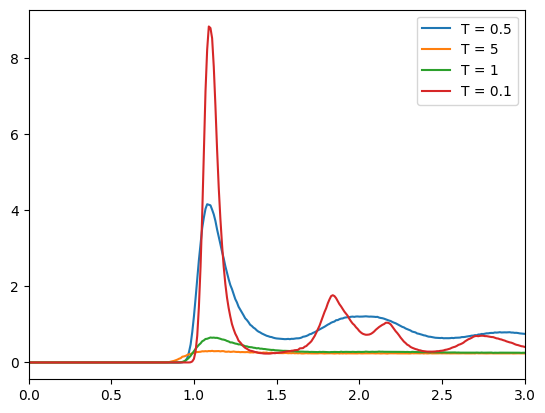

In [ ]:
for file in gr:
    print(file)
    data = np.loadtxt('RESULTS/' + file)
    t = file.split("_")[0].replace("dp",".")
    r = data[:,0]
    g_r = data[:,1]
    print(r)
    print(g_r)
    plt.plot(r,g_r,label=f"T = {t}")
plt.xlim(0,3)
plt.legend()